# Name: Malak Gamal Ahmed Sanad Eleza
# ID: 221000014

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [30]:
# ── Load 10 selected columns
COLS = ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'BMI',
        'Smoker', 'Diabetes', 'PhysActivity', 'GenHlth', 'Sex', 'Age', 'Income']

df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv', usecols=COLS)

print('=== Dataset Overview ===')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

=== Dataset Overview ===
Shape: (253680, 11)
Columns: ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Diabetes', 'PhysActivity', 'GenHlth', 'Sex', 'Age', 'Income']


,HeartDiseaseorAttack,HighBP,HighChol,BMI,Smoker,Diabetes,PhysActivity,GenHlth,Sex,Age,Income
0,0.0,1.0,1.0,40.0,1.0,0.0,0.0,5.0,0.0,9.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,1.0,3.0,0.0,7.0,1.0
2,0.0,1.0,1.0,28.0,0.0,0.0,0.0,5.0,0.0,9.0,8.0
3,0.0,1.0,0.0,27.0,0.0,0.0,1.0,2.0,0.0,11.0,6.0
4,0.0,1.0,1.0,24.0,0.0,0.0,1.0,2.0,0.0,11.0,4.0


In [31]:
# ── Check data types and missing values
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Data Types ===
HeartDiseaseorAttack    float64
HighBP                  float64
HighChol                float64
BMI                     float64
Smoker                  float64
Diabetes                float64
PhysActivity            float64
GenHlth                 float64
Sex                     float64
Age                     float64
Income                  float64
dtype: object

=== Missing Values ===
HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
BMI                     0
Smoker                  0
Diabetes                0
PhysActivity            0
GenHlth                 0
Sex                     0
Age                     0
Income                  0
dtype: int64

Total missing: 0


In [32]:
# ── Descriptive Statistics
df.describe()

,HeartDiseaseorAttack,HighBP,HighChol,BMI,Smoker,Diabetes,PhysActivity,GenHlth,Sex,Age,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.094186,0.429001,0.424121,28.382364,0.443169,0.296921,0.756544,2.511392,0.440342,8.032119,6.053875
std,0.292087,0.494934,0.494210,6.608694,0.496761,0.698160,0.429169,1.068477,0.496429,3.054220,2.071148
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,1.000000,2.000000,0.000000,6.000000,5.000000
50%,0.000000,0.000000,0.000000,27.000000,0.000000,0.000000,1.000000,2.000000,0.000000,8.000000,7.000000
75%,0.000000,1.000000,1.000000,31.000000,1.000000,0.000000,1.000000,3.000000,1.000000,10.000000,8.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,2.000000,1.000000,5.000000,1.000000,13.000000,8.000000


In [33]:
# ── Class imbalance check
print('=== Target Variable Distribution ===')
print(df['HeartDiseaseorAttack'].value_counts())
print(f'\nClass imbalance ratio: {df["HeartDiseaseorAttack"].mean():.1%} positive cases')

# ── Cleaning: Cap BMI outliers (>80 are data entry errors)
print(f'\nBMI before capping — max: {df["BMI"].max()}')
df['BMI'] = df['BMI'].clip(upper=80)
print(f'BMI after capping — max: {df["BMI"].max()}')
print('\n✅ Data cleaning complete: BMI outliers capped at 80')

=== Target Variable Distribution ===
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

Class imbalance ratio: 9.4% positive cases

BMI before capping — max: 98.0
BMI after capping — max: 80.0

✅ Data cleaning complete: BMI outliers capped at 80


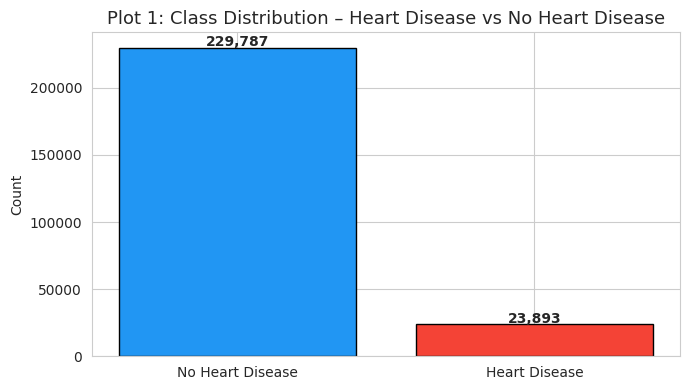

In [34]:
# ── Plot 1: Class Distribution (Bar Chart – Univariate)
colors = ['#2196F3', '#F44336']
fig, ax = plt.subplots(figsize=(7, 4))
vals = df['HeartDiseaseorAttack'].value_counts()
bars = ax.bar(['No Heart Disease', 'Heart Disease'], vals.values, color=colors, edgecolor='black')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1000,
            f'{b.get_height():,}', ha='center', fontweight='bold')
ax.set_title('Plot 1: Class Distribution – Heart Disease vs No Heart Disease', fontsize=13)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

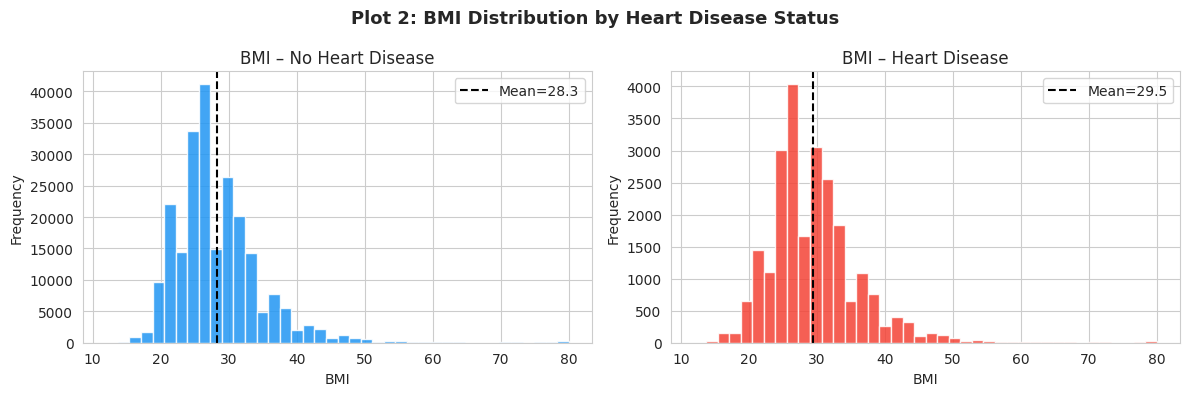

In [35]:
# ── Plot 2: BMI Histogram by Target (Histogram – Bivariate)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (label, grp) in enumerate(df.groupby('HeartDiseaseorAttack')['BMI']):
    axes[i].hist(grp, bins=40, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f"BMI – {'Heart Disease' if label else 'No Heart Disease'}")
    axes[i].axvline(grp.mean(), color='black', linestyle='--', label=f'Mean={grp.mean():.1f}')
    axes[i].set_xlabel('BMI'); axes[i].set_ylabel('Frequency')
    axes[i].legend()
plt.suptitle('Plot 2: BMI Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

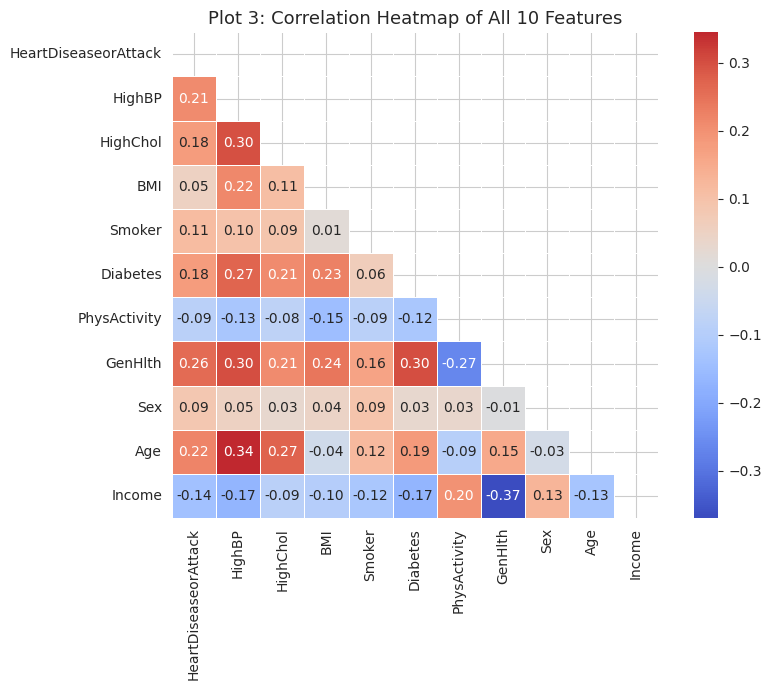

In [36]:
# ── Plot 3: Correlation Heatmap (Heatmap – Multivariate)
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('Plot 3: Correlation Heatmap of All 10 Features', fontsize=13)
plt.tight_layout()
plt.show()

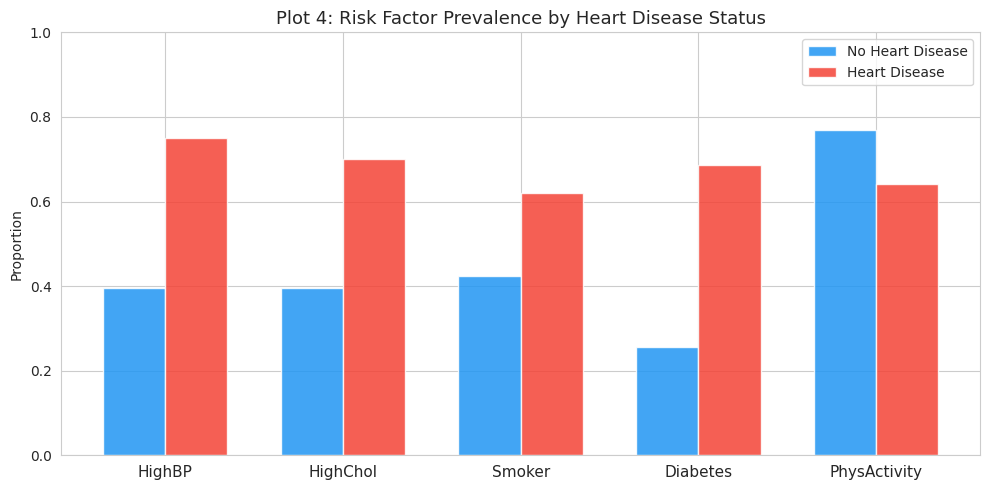

Key insight: HighBP, Diabetes, and lack of PhysActivity show the strongest differences.


In [37]:
# ── Plot 4: Grouped Bar – Risk Factor Prevalence (Bivariate)
risk_factors = ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'PhysActivity']
rates = df.groupby('HeartDiseaseorAttack')[risk_factors].mean().T
rates.columns = ['No Heart Disease', 'Heart Disease']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(risk_factors)); w = 0.35
ax.bar(x - w/2, rates['No Heart Disease'], w, label='No Heart Disease', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, rates['Heart Disease'],    w, label='Heart Disease',    color='#F44336', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(risk_factors, fontsize=11)
ax.set_ylabel('Proportion'); ax.set_ylim(0, 1)
ax.set_title('Plot 4: Risk Factor Prevalence by Heart Disease Status', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('Key insight: HighBP, Diabetes, and lack of PhysActivity show the strongest differences.')

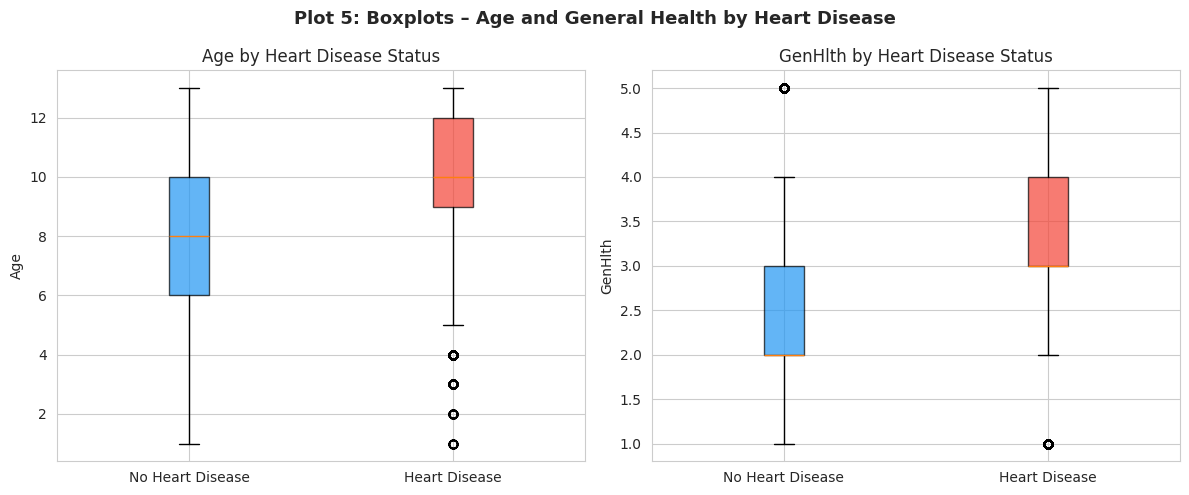

In [38]:
# ── Plot 5: Boxplots – Age & GenHlth (Box Plot – Bivariate)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['Age', 'GenHlth']):
    data = [df[df['HeartDiseaseorAttack'] == 0][col],
            df[df['HeartDiseaseorAttack'] == 1][col]]
    bp = ax.boxplot(data, patch_artist=True, labels=['No Heart Disease', 'Heart Disease'])
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(f'{col} by Heart Disease Status')
    ax.set_ylabel(col)
plt.suptitle('Plot 5: Boxplots – Age and General Health by Heart Disease', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

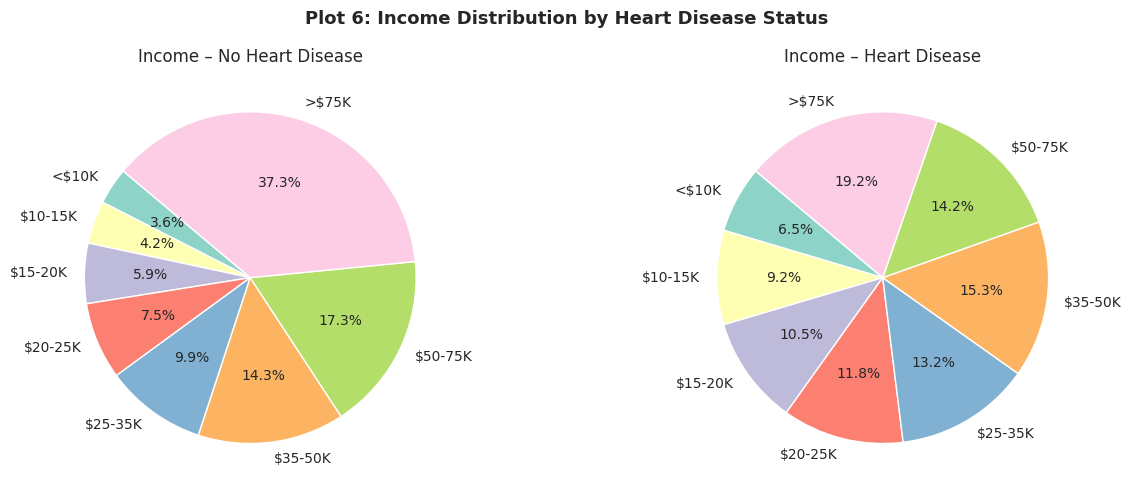

In [39]:
# ── Plot 6: Pie Charts – Income Distribution (Pie Chart – Univariate per class)
labels_income = ['<$10K','$10-15K','$15-20K','$20-25K','$25-35K','$35-50K','$50-75K','>$75K']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (label, grp) in enumerate(df.groupby('HeartDiseaseorAttack')['Income']):
    counts = grp.value_counts().sort_index()
    axes[i].pie(counts, labels=labels_income, autopct='%1.1f%%',
                startangle=140, colors=sns.color_palette('Set3', 8))
    axes[i].set_title(f"Income – {'Heart Disease' if label else 'No Heart Disease'}")
plt.suptitle('Plot 6: Income Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# ── New Feature 1: Health_Risk_Score
# Sum of 5 binary risk indicators (higher = more at-risk)
df['Health_Risk_Score'] = (
    df['HighBP'] + df['HighChol'] + df['Smoker'] +
    df['Diabetes'] + (1 - df['PhysActivity'])
)
print('Feature 1: Health_Risk_Score (0–5)')
print(df['Health_Risk_Score'].value_counts().sort_index())

# ── New Feature 2: BMI_Category (ordinal)
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 80],
    labels=[0, 1, 2, 3]   # Underweight, Normal, Overweight, Obese
).astype(int)
print('\nFeature 2: BMI_Category (0=Under, 1=Normal, 2=Over, 3=Obese)')
print(df['BMI_Category'].value_counts().sort_index())

Feature 1: Health_Risk_Score (0–5)
Health_Risk_Score
0.0    51149
1.0    70091
2.0    58510
3.0    37508
4.0    20119
5.0    12003
6.0     4300
Name: count, dtype: int64

Feature 2: BMI_Category (0=Under, 1=Normal, 2=Over, 3=Obese)
BMI_Category
0     3127
1    86099
2    91176
3    73278
Name: count, dtype: int64


In [41]:
import numpy as np
# ── Feature Selection: Filter Method (ANOVA F-test)

# Drop rows with any NaN values to handle missing data before feature selection
# There are only 2 missing values across the entire dataset, so dropping them is safe.
df_cleaned = df.dropna()

X_all = df_cleaned.drop('HeartDiseaseorAttack', axis=1)
y = df_cleaned['HeartDiseaseorAttack']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y)
feat_scores = pd.Series(selector.scores_, index=X_all.columns).sort_values(ascending=False)

print('=== Feature Importance (ANOVA F-scores) ===')
print(feat_scores)

# Select top 10 features
top_features = feat_scores.nlargest(10).index.tolist()
print(f'\n✅ Top 10 selected features: {top_features}')
X = X_all[top_features]

=== Feature Importance (ANOVA F-scores) ===
Health_Risk_Score    21145.201953
GenHlth              18147.618073
Age                  13102.770824
HighBP               11628.965846
HighChol              8569.219931
Diabetes              8520.908912
Income                5146.509879
Smoker                3366.457880
PhysActivity          1948.155850
Sex                   1894.414298
BMI_Category           858.125329
BMI                    726.743581
dtype: float64

✅ Top 10 selected features: ['Health_Risk_Score', 'GenHlth', 'Age', 'HighBP', 'HighChol', 'Diabetes', 'Income', 'Smoker', 'PhysActivity', 'Sex']


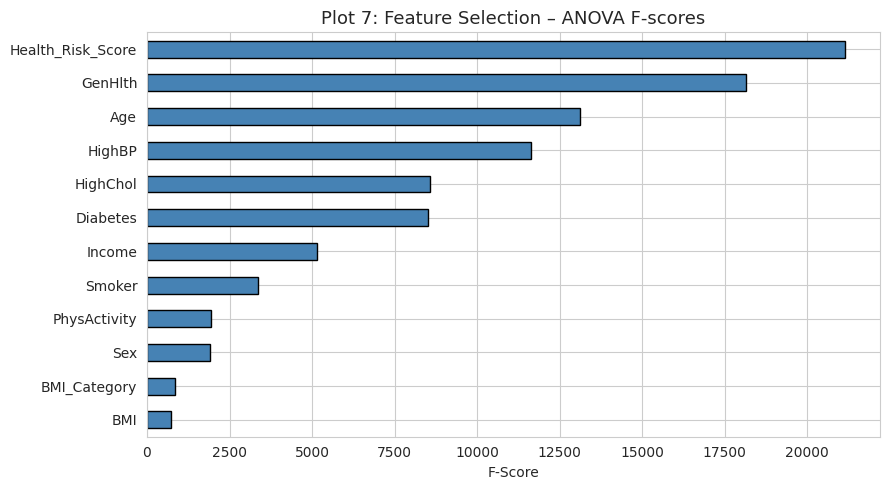

In [42]:
# ── Plot 7: Feature Selection Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))
feat_scores.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Plot 7: Feature Selection – ANOVA F-scores', fontsize=13)
ax.set_xlabel('F-Score')
plt.tight_layout()
plt.show()

In [43]:
# ── Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

# ── Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Training set: (202944, 10)
Test set:     (50736, 10)


In [44]:
# ── Helper: evaluate a trained model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Fit model and return performance metrics dict."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]
    return {
        'Model':     name,
        'Precision': round(precision_score(y_te, pred), 4),
        'Recall':    round(recall_score(y_te, pred),    4),
        'F1':        round(f1_score(y_te, pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_te, prob),   4)
    }

results = []

In [45]:
# ── Algorithm 1: Logistic Regression
# Uses class_weight='balanced' to handle class imbalance
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
r1 = evaluate_model('Logistic Regression', lr, X_train_sc, X_test_sc, y_train, y_test)
results.append(r1)
print('Logistic Regression results:', r1)

Logistic Regression results: {'Model': 'Logistic Regression', 'Precision': 0.2387, 'Recall': 0.7962, 'F1': 0.3672, 'ROC-AUC': np.float64(0.8388)}


In [46]:
# ── Algorithm 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
r2 = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)
results.append(r2)
print('Random Forest results:', r2)

Random Forest results: {'Model': 'Random Forest', 'Precision': 0.2394, 'Recall': 0.5844, 'F1': 0.3397, 'ROC-AUC': np.float64(0.7518)}


In [47]:
# ── Algorithm 3: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=50, max_depth=4, random_state=42)
r3 = evaluate_model('Gradient Boosting', gb, X_train, X_test, y_train, y_test)
results.append(r3)
print('Gradient Boosting results:', r3)

Gradient Boosting results: {'Model': 'Gradient Boosting', 'Precision': 0.5225, 'Recall': 0.0607, 'F1': 0.1087, 'ROC-AUC': np.float64(0.8412)}


In [48]:
# ── GridSearchCV – Tune Logistic Regression
param_grid = {
    'C':      [0.001, 0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_sc, y_train)
best_lr = grid.best_estimator_
print(f'Best params: {grid.best_params_}')

pred_best = best_lr.predict(X_test_sc)
prob_best  = best_lr.predict_proba(X_test_sc)[:, 1]
tuned = {
    'Model':     'Tuned LR (GridSearch)',
    'Precision': round(precision_score(y_test, pred_best), 4),
    'Recall':    round(recall_score(y_test, pred_best),    4),
    'F1':        round(f1_score(y_test, pred_best),        4),
    'ROC-AUC':   round(roc_auc_score(y_test, prob_best),   4)
}
results.append(tuned)
print('Tuned LR:', tuned)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'C': 10, 'solver': 'liblinear'}
Tuned LR: {'Model': 'Tuned LR (GridSearch)', 'Precision': 0.2387, 'Recall': 0.7962, 'F1': 0.3672, 'ROC-AUC': np.float64(0.8388)}


In [49]:
# ── Results Table
results_df = pd.DataFrame(results)
print('=== Model Comparison ===')
results_df

=== Model Comparison ===


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.2387,0.7962,0.3672,0.8388
1,Random Forest,0.2394,0.5844,0.3397,0.7518
2,Gradient Boosting,0.5225,0.0607,0.1087,0.8412
3,Tuned LR (GridSearch),0.2387,0.7962,0.3672,0.8388


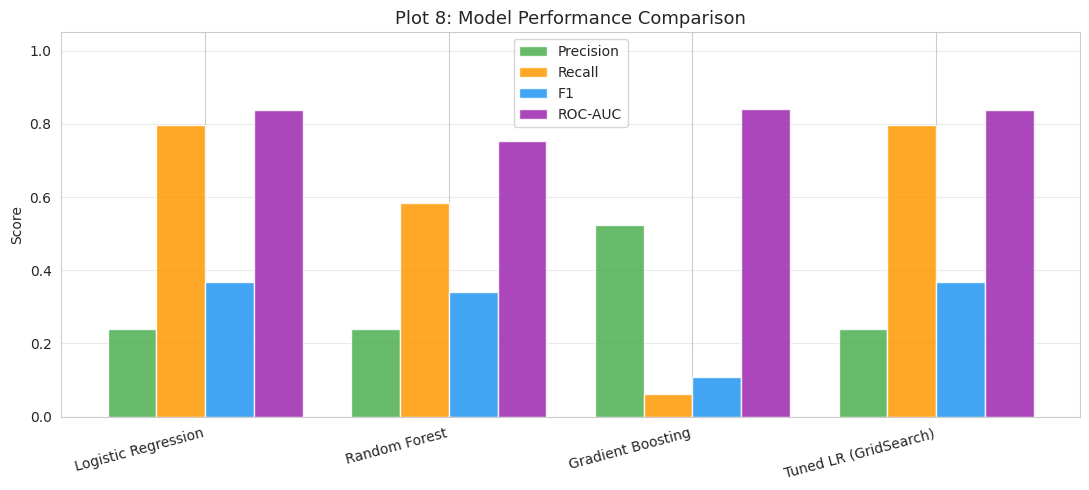

In [50]:
# ── Plot 8: Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df)); w = 0.2
metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
bar_colors = ['#4CAF50', '#FF9800', '#2196F3', '#9C27B0']
for i, m in enumerate(metrics):
    ax.bar(x + i*w, results_df[m], w, label=m, color=bar_colors[i], alpha=0.85)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Plot 8: Model Performance Comparison', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

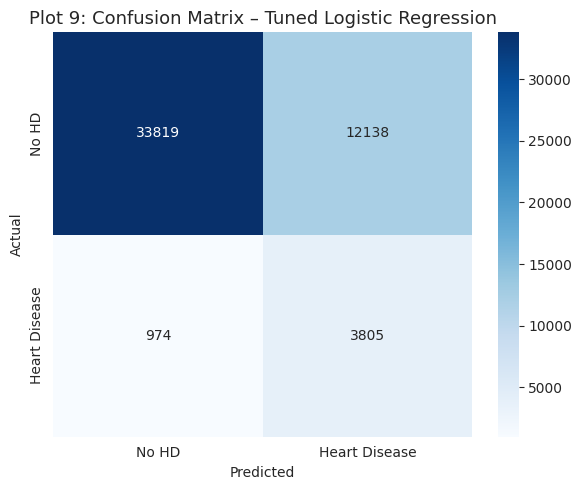


=== Classification Report ===
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.74      0.84     45957
   Heart Disease       0.24      0.80      0.37      4779

        accuracy                           0.74     50736
       macro avg       0.61      0.77      0.60     50736
    weighted avg       0.90      0.74      0.79     50736



In [51]:
# ── Plot 9: Confusion Matrix (Best Model)
cm = confusion_matrix(y_test, pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_title('Plot 9: Confusion Matrix – Tuned Logistic Regression', fontsize=13)
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\n=== Classification Report ===')
print(classification_report(y_test, pred_best, target_names=['No Heart Disease', 'Heart Disease']))

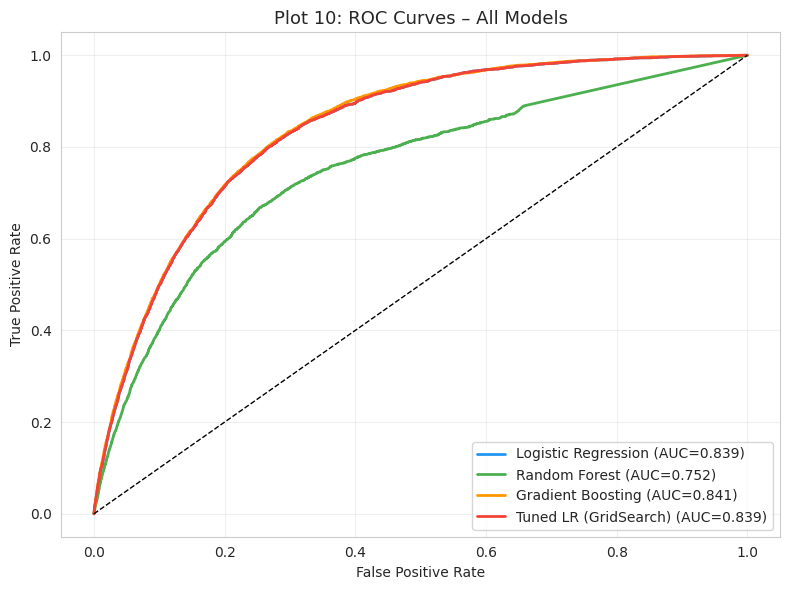

In [52]:
# ── Plot 10: ROC Curves – All Models
fig, ax = plt.subplots(figsize=(8, 6))
model_info = [
    ('Logistic Regression', lr,      X_test_sc),
    ('Random Forest',       rf,      X_test.values),
    ('Gradient Boosting',   gb,      X_test.values),
    ('Tuned LR (GridSearch)', best_lr, X_test_sc),
]
roc_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
for (name, m, Xte), c in zip(model_info, roc_colors):
    p = m.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Plot 10: ROC Curves – All Models', fontsize=13)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# ── Save best model, scaler, and feature list
joblib.dump(best_lr,       'best_model.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(top_features,  'selected_features.pkl')

print('✅ Saved: best_model.pkl')
print('✅ Saved: scaler.pkl')
print('✅ Saved: selected_features.pkl')
print('\n=== Project Complete ===')

✅ Saved: best_model.pkl
✅ Saved: scaler.pkl
✅ Saved: selected_features.pkl

=== Project Complete ===
